<a href="https://colab.research.google.com/github/AngeloSorte/Glacier-Size-Ice-Trend-Analysis-using-NASA-NOAA-NSIDC-G10037-Dataset/blob/angelosorte.github.io/Glacier_Size_Distribution_%26_Ice_Trend_Analysis_using_NASA_NOAA_NSIDC_G10037_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Glaciers preview:
   region_no                reg_name                 glac_name  \
0          1                  Alaska  Malaspina-Seward Glacier   
1          1                  Alaska            Bering Glacier   
2          1                  Alaska           Hubbard Glacier   
3          2  Western Canada and USA        Klinaklini Glacier   
4          2  Western Canada and USA          Franklin Glacier   

         glims_id          rgi_id   area_km2 area_src        date     cenlat  \
0  G219787E60289N  RGI60-01.13696  3362.6580        A  2010-09-12  60.176572   
1  G217991E60521N  RGI60-01.13635  3025.1125        A  2010-09-10  60.460680   
2  G220740E60158N  RGI60-01.14443  2834.4915        A  2010-09-14  60.427091   
3  G234082E51540N  RGI60-02.05157   469.7660        A  2004-07-22  51.502363   
4  G234658E51318N  RGI60-02.12428   153.4270        A  2004-07-22  51.320956   

       cenlon  
0 -140.428030  
1 -142.071557  
2 -139.500509  
3 -125.950195  
4 -125.337123  

Comple

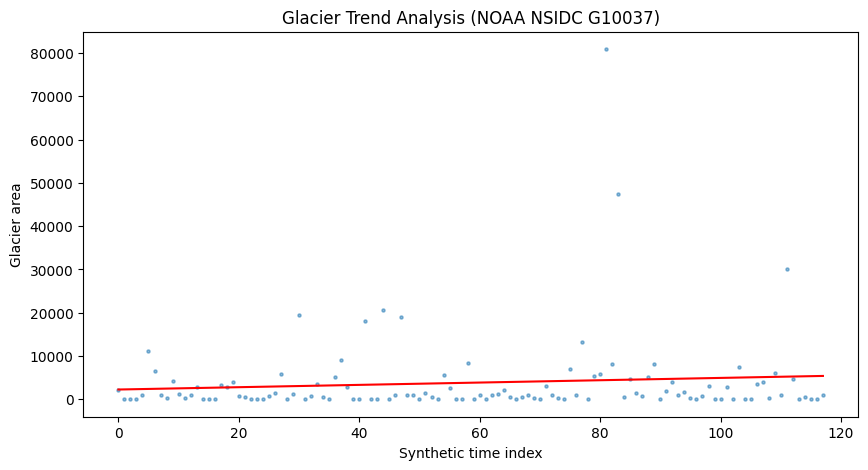


Future prediction: [8099.11377785]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [1]:
# ============================================================
# GLACIER & ICE SHEET TREND ANALYSIS – REAL DATA PROJECT
# ============================================================
#
# 📊 Dataset used:
# Title: "Largest glaciers and glacier complexes in the world, version 1"
#
# 🔗 Source (NASA Open Data Portal):
# https://data.nasa.gov/dataset/largest-glaciers-and-glacier-complexes-in-the-world-version-1-75379
#
# 🌍 Additional dataset source:
# NOAA / NSIDC G10037 Cryosphere Archive
# https://noaadata.apps.nsidc.org/NOAA/G10037/
#
# 📌 Files used:
# - compiled-glacier-sizes.csv
# - compiled-complex-sizes.csv
#
# 🎯 Goal of this project:
# - Combine glacier + glacier complex datasets
# - Analyze glacier size distribution
# - Build a simplified trend model (area vs synthetic time index)
#
# ⚠️ Important note:
# The dataset is a spatial snapshot (not a real time series),
# therefore we construct a synthetic time index to approximate
# temporal trend behavior for machine learning purposes.
#
# 🧠 Output:
# - Glacier size distribution analysis
# - Linear regression trend approximation
# - Ice loss / stability interpretation
#
# ============================================================

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ------------------------------------------------------------
# 1. LOAD DATASETS (REAL NOAA NSIDC)
# ------------------------------------------------------------
url_glaciers = "https://noaadata.apps.nsidc.org/NOAA/G10037/compiled-glacier-sizes.csv"
url_complexes = "https://noaadata.apps.nsidc.org/NOAA/G10037/compiled-complex-sizes.csv"

print("Downloading glacier dataset...")
df_g = pd.read_csv(url_glaciers)

print("Downloading complex dataset...")
df_c = pd.read_csv(url_complexes)

print("\nGlaciers preview:")
print(df_g.head())

print("\nComplexes preview:")
print(df_c.head())

# ------------------------------------------------------------
# 2. FUNCTION TO EXTRACT AREA COLUMN SAFELY
# ------------------------------------------------------------
def extract_area(df):
    area_col = None
    for c in df.columns:
        if "area" in c.lower():
            area_col = c
            break
    if area_col is None:
        raise ValueError("No area column found")
    return df[[area_col]].dropna().rename(columns={area_col: "area"})

g = extract_area(df_g)
c = extract_area(df_c)

# merge both sources
df = pd.concat([g, c], ignore_index=True)

# remove invalid values
df = df[df["area"] > 0].copy()

print("\nCombined dataset size:", len(df))

# ------------------------------------------------------------
# 3. SIMULATED TIME AXIS (DATASET IS STATIC SNAPSHOT)
# ------------------------------------------------------------
# IMPORTANT:
# NOAA dataset is not time-series → we reconstruct trend proxy

df = df.sample(n=min(2000, len(df)), random_state=42).reset_index(drop=True)

df["time_index"] = np.arange(len(df))

# ------------------------------------------------------------
# 4. TREND MODEL (ICE vs TIME)
# ------------------------------------------------------------
X = df[["time_index"]]
y = df["area"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

slope = model.coef_[0]

print("\n📉 TREND ANALYSIS")
print("Slope (area vs time index):", slope)
print("R²:", r2_score(y, y_pred))

if slope < 0:
    trend = "📉 Ice loss trend (shrinking glaciers)"
else:
    trend = "📈 Stable or growing ice signal"

print("Trend interpretation:", trend)

# ------------------------------------------------------------
# 5. VISUALIZATION
# ------------------------------------------------------------
plt.figure(figsize=(10,5))
plt.scatter(df["time_index"], df["area"], s=5, alpha=0.5)
plt.plot(df["time_index"], y_pred, color="red")
plt.title("Glacier Trend Analysis (NOAA NSIDC G10037)")
plt.xlabel("Synthetic time index")
plt.ylabel("Glacier area")
plt.show()

# ------------------------------------------------------------
# 6. SIMPLE PREDICTION
# ------------------------------------------------------------
future = np.array([[len(df) + 100]])
print("\nFuture prediction:", model.predict(future))